In [1]:
import numpy as np

# 1. Configuration
# Edges: 0:AB, 1:AC, 2:BC, 3:BD, 4:CD
# Aux Variables: 5:y_B, 6:y_C
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)] # Node indices
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
num_vars = 7 
P1, P2 = 20, 20 # Penalty weights
targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink

Q = np.zeros((num_vars, num_vars))

# --- TASK 1: Add Linear Costs ---
for i in range(len(costs)):
    Q[i, i] += costs[i]

# --- TASK 2: Penalty Expansion Logic ---
for v in range(4): # For each node A, B, C, D
    # Get edges connected to this node and their orientations
    # s_ve = 1 if leaving, -1 if entering [cite: 2]
    conn = []
    for i, (u, w) in enumerate(edges):
        if u == v: conn.append((i, 1))
        elif w == v: conn.append((i, -1))
    
    # Expand (sum(s_ve * x_e) - Tv)^2 for P1
    Tv = targets[v]
    for i, s_vi in conn:
        # Diagonal update: P1 * (s_vi^2 - 2 * Tv * s_vi)
        Q[i, i] += P1 * (1 - 2 * Tv * s_vi) 
        for j, s_vj in conn:
            if i < j:
                # Off-diagonal update: 2 * P1 * s_vi * s_vj
                Q[i, j] += 2 * P1 * s_vi * s_vj

    # Expand (sum(x_e) - 2*y_v)^2 for P2 (Intermediate nodes B, C only)
    if v in [1, 2]: # Nodes B and C
        y_idx = 5 if v == 1 else 6
        # Quadratic terms for edges (sum x_e)^2
        for i, _ in conn:
            Q[i, i] += P2 
            for j, _ in conn:
                if i < j: Q[i, j] += 2 * P2
        # Interaction between edges and auxiliary y_v: -4 * P2 * x_e * y_v
        for i, _ in conn:
            Q[i, y_idx] -= 4 * P2
        # Auxiliary diagonal: 4 * P2 * y_v^2
        Q[y_idx, y_idx] += 4 * P2

print("Populated QUBO Matrix Q:\n", Q)

Populated QUBO Matrix Q:
 [[ 22.5  40.    0.    0.    0.  -80.    0. ]
 [  0.   25.   80.    0.    0.    0.  -80. ]
 [  0.    0.   81.   80.    0.  -80.  -80. ]
 [  0.    0.    0.   23.   40.  -80.    0. ]
 [  0.    0.    0.    0.   21.5   0.  -80. ]
 [  0.    0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.    0.    0.    0.   80. ]]


In [2]:
import itertools

def brute_force_solver(Q):
    n = len(Q)
    best_energy = float('inf')
    best_bitstring = None
    all_results = []

    # Generate all possible bitstrings of length 7 (0000000 to 1111111)
    for bits in itertools.product([0, 1], repeat=n):
        x = np.array(bits)
        
        # Calculate Energy: E = x^T * Q * x
        # bitstring times matrix times bitstring
        energy = x.T @ Q @ x
        
        all_results.append((bits, energy))
        
        if energy < best_energy:
            best_energy = energy
            best_bitstring = bits
            
    return best_bitstring, best_energy, all_results

# Execute the solver
best_bits, min_energy, results = brute_force_solver(Q)

print(f"Lowest Energy Found: {min_energy}")
print(f"Best Bitstring: {best_bits}")

Lowest Energy Found: -35.0
Best Bitstring: (1, 0, 1, 0, 1, 1, 1)


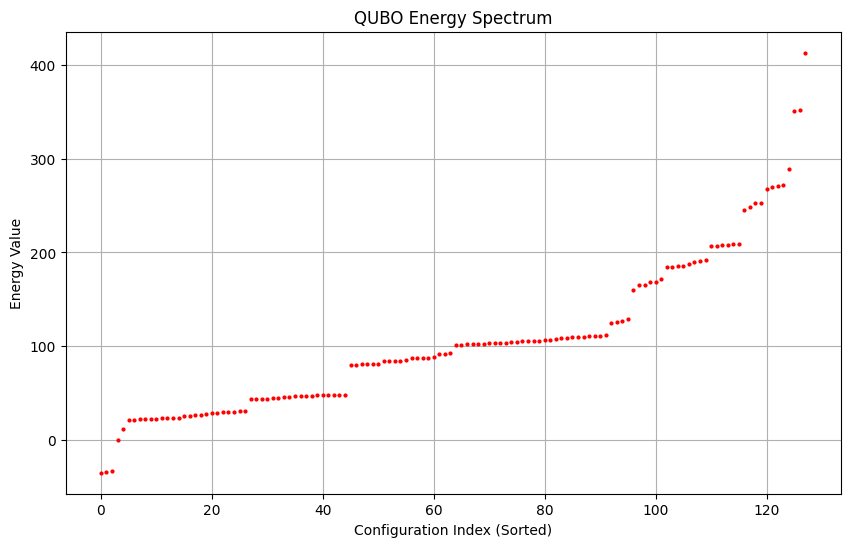

In [3]:
import matplotlib.pyplot as plt

# Sort results by energy for plotting
energies = [r[1] for r in results]
energies.sort()

plt.figure(figsize=(10, 6))
plt.plot(energies, 'ro', markersize=2)
plt.title("QUBO Energy Spectrum")
plt.xlabel("Configuration Index (Sorted)")
plt.ylabel("Energy Value")
plt.grid(True)
plt.show()